In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os
import numpy as np
from pathlib import Path

# Path.cwd() gets the current working directory (where your notebook lives)
# .parents[1] moves up two directories (equivalent to '../../')
project_root = Path.cwd().parents[1]

sys.path.insert(0, str(project_root.resolve()))
from src.simulations.GBM import (
    estimate_parameters,
    simulate_paths,
    simulate_paths2,
    simulate_correlated_GBM,
    estimate_Correlation_matrix
)
from src.data.statistics import compute_log_returns
from src.risk.var import loss_distribution

# Assuming returns is your log-return dataframe
AAPL=pd.read_parquet(r"..\data\raw\AAPL.parquet")
NVDA=pd.read_parquet(r"..\data\raw\NVDA.parquet")
JPM=pd.read_parquet(r"..\data\raw\JPM.parquet")
SPY=pd.read_parquet(r"..\data\raw\SPY.parquet")
prices = pd.DataFrame({
    "AAPL": AAPL["adj_close"],
    "NVDA":NVDA['adj_close'],
    "JPM":JPM["adj_close"],
    "SPY":SPY['adj_close']
})
returns = compute_log_returns(prices)

In [3]:
prices=prices.dropna()

In [4]:
prices

,AAPL,NVDA,JPM,SPY
0,72.271538,5.963804,117.899185,296.888123
1,71.568909,5.868347,116.343338,294.640137
2,72.139206,5.892956,116.250839,295.764099
3,71.799911,5.964301,114.274506,294.932495
4,72.954918,5.975487,115.165993,296.504425
...,...,...,...,...
1610,306.046051,224.098816,295.249908,758.539978
1611,314.928406,222.560608,299.610260,759.570007
1612,309.992645,214.500000,299.500793,754.239990
1613,310.961823,218.660004,309.495758,757.090027


This snippet simulates the paths of the correlated prices of the four stocks we are simulating.

paths[-1] would represent the last prices of the stocks. \
The values are in log returns. 

The whole history of returns is used to estimate the statistical properties of the market, such as correlations, volatility, and drift.

We use the historical return to estimate how these assets tend to move together, **then** we use that relationship for our Monte Carlo simulation.

In [3]:
corraleted_matrix=estimate_Correlation_matrix(returns)
n_paths=5000
n_assets=4
years=3
steps_per_year=252
paths=simulate_correlated_GBM(
    corr_matrix=corraleted_matrix,
    prices=prices,
    returns=returns,
    n_paths=n_paths,
    n_assets=n_assets,
    years=years,
    steps_per_year=steps_per_year,
)

In [4]:
historical_return = prices.iloc[-1] / prices.iloc[0] - 1
simulated_returns = paths[-1]/paths[0] - 1
print(historical_return)
for i in range(4):
    print(np.mean(simulated_returns[i,:]))

AAPL     3.262594
NVDA    34.985411
JPM      1.590046
SPY      1.528191
dtype: float64
0.9508188464478604
4.386691238466389
0.554294342642172
0.5386882596302875


<div align="center">
  The historical return is much bigger than the simulated return. 
Nonetheless we do have to take into acount that the historical return spans over 25 years, the simulated return expands across 3 years.
</div>

In [5]:
mu = (returns.mean() * 252).to_numpy()
sigma = (returns.std() * np.sqrt(252)).to_numpy()
print(f"Theoretical mean: {mu},\n Theoretical sigma: {sigma}")
simulated_mu = np.mean(simulated_returns[:4, :], axis=1)
simulated_sigma = np.std(simulated_returns[:4, :], axis=1)
print(f"Simulated mean: {simulated_mu},\n Simulated sigma{simulated_sigma}")

Theoretical mean: [0.22750262 0.56223202 0.14932896 0.14553615],
 Theoretical sigma: [0.31314999 0.52045169 0.30932244 0.20422683]
Simulated mean: [0.95081885 4.38669124 0.55429434 0.53868826],
 Simulated sigma[1.11295245 6.05092904 0.85830941 0.54662034]


<div align="center">

The theoretical mean and the simulated mean are extremely different. Also the sigmas appear to be very different. 
Why might this be?
At first I thought that it might be because the historical $\mu$ is measured from 25 years of historical data, while $\mu_{sim}$ is simulated for 3 years.

I think it would be a mistake to think that the mean would be the same across these many years. 

$\mu$  is measured by calculating the returns of the historical data(from 2000 to 2023, i think), while $\mu_{sim}$ is measured by running the montecarlo simulation and using the predicted prices from 2023 to 2026, so of course they are not going to be the same, they are not measuring the same things.

</div>


In [6]:
T = 756 / 252

theoretical_mean = (mu - 0.5*sigma**2) * T
theoretical_std  = sigma * np.sqrt(T)

print(f"Theoretical mean: {theoretical_mean}")
print(f"Theoretical std: {theoretical_std}")
terminal_log_returns = np.log(paths[-1] / paths[0])

sim_mean = np.mean(terminal_log_returns, axis=1)
sim_std  = np.std(terminal_log_returns, axis=1)

print(f"Simulated mean: {sim_mean}")
print(f"Simulated std: {sim_std}")

Theoretical mean: [0.53541348 1.28039113 0.30446631 0.37404556]
Theoretical std: [0.5423917  0.90144876 0.53576218 0.35373125]
Simulated mean: [0.52666608 1.27677965 0.30596727 0.37113642]
Simulated std: [0.53377617 0.90415653 0.52137918 0.34634076]


<div align="center">

What are we printing here? Why do these results look alike?

theoretical_mean is calculated by using the previous mu and sigma (the one calculated with the historical data) and used the **time evolution** to find what the value would be like at year three. The same for theoretical_std.

For sim_mean and sim_std we just had to measure the log_return of the paths, we don't have to take into account the time T since it's already considered for in the simulations.

</div>

In [7]:
returns_hist=returns.to_numpy()
#returns_hist=np.transpose(returns_hist)
print(returns_hist.shape)
losses_historical=loss_distribution(paths=returns_hist)
print(losses_historical.shape)

print(losses_historical)

(1606, 4)
NaNs at t0: 0
NaNs at tT: 0
(4,)
[-0.0081819  -0.01395024 -0.01445837 -0.01421731]


<div align='center'>

Why are the historical losses so small? They actually should be negative since it's almost sure all stocks grew. 
**returns** is not the same thing as prices. You can have a constant return, while the price grows, or falls. 
But does it make sense that the returns are almost zero? They can be constant, but zero?

</div>

(array([  1.,   0.,   2.,   2.,   2.,   7.,  23.,  82., 189., 562., 478.,
        183.,  52.,  10.,   5.,   3.,   3.,   1.,   0.,   1.]),
 array([-0.1377081 , -0.12369183, -0.10967555, -0.09565928, -0.08164301,
        -0.06762673, -0.05361046, -0.03959419, -0.02557791, -0.01156164,
         0.00245464,  0.01647091,  0.03048718,  0.04450346,  0.05851973,
         0.072536  ,  0.08655228,  0.10056855,  0.11458482,  0.1286011 ,
         0.14261737]),
 <BarContainer object of 20 artists>)

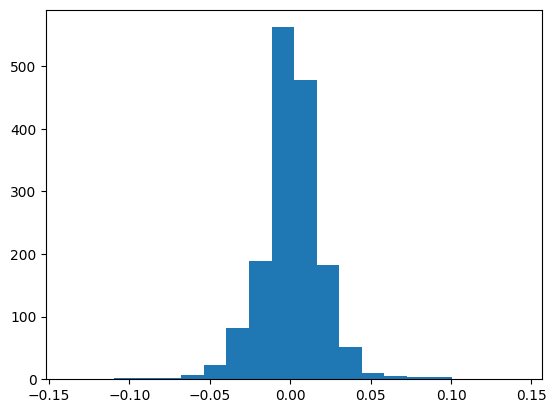

In [22]:
plt.hist(returns.AAPL, bins=20)

<div align="center">

With this histogram we can see that the returns range basically from -0.10 to 0.10.
That is the reason why the historical returns are near zero. The returns basically cancel each other out. But it still doesn't make, sense since we expect the price to go up. 

The confusing part is that I was confusing the behavior of daily returns with the behavior of the stock price over several years.

Returns don't add together, prices compound. 

So, **how can the average return be negative?** This is where we need to distiniguish arithmetic mean, geometric growth and log return. If we had something like [+5%,-4%,+3%....] the arithmetic average of the return could be close to zero, instead, it's related to 
$$
g \approx \mu-\frac{1}{2}\sigma^2
$$
where g is approximate continuously compounded growth rate. 


</div>

In [ ]:
losses=paths[0]-paths[-1] 
"""
The unit of losses is price. We can have negative values because paths is the difference
between the first price and last. Generally, paths alone shoould be non-negative
"""

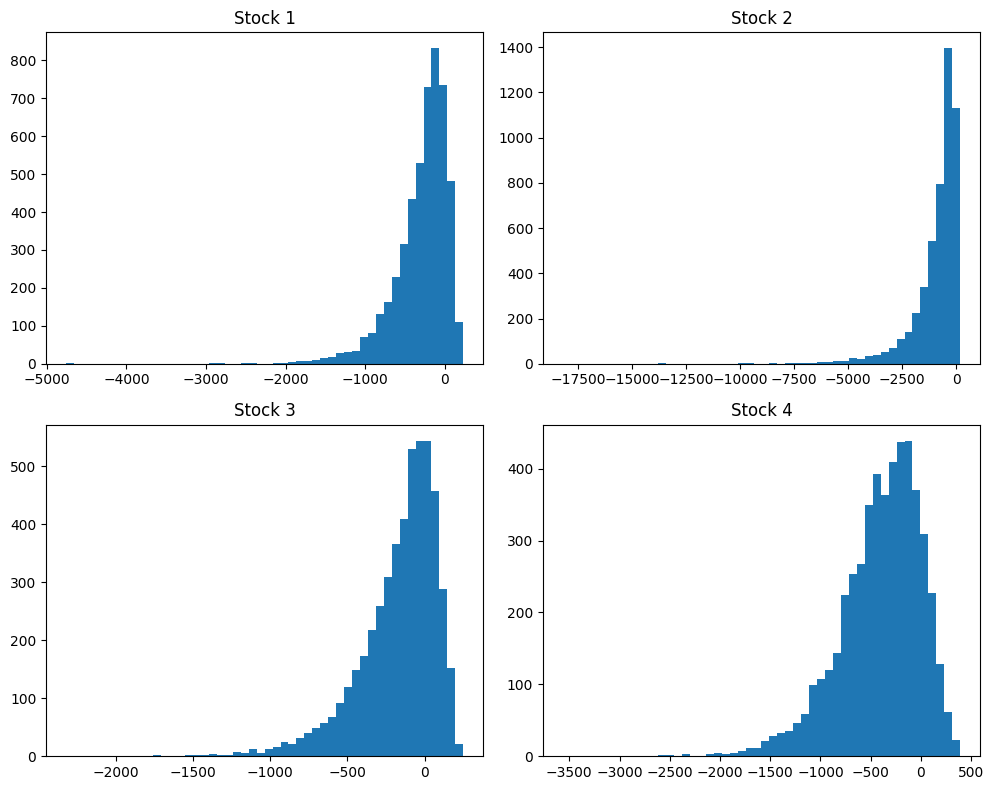

In [9]:

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, ax in enumerate(axes.flatten()):
    ax.hist(losses[i], bins=50)
    ax.set_title(f"Stock {i+1}")

plt.tight_layout()
plt.show()

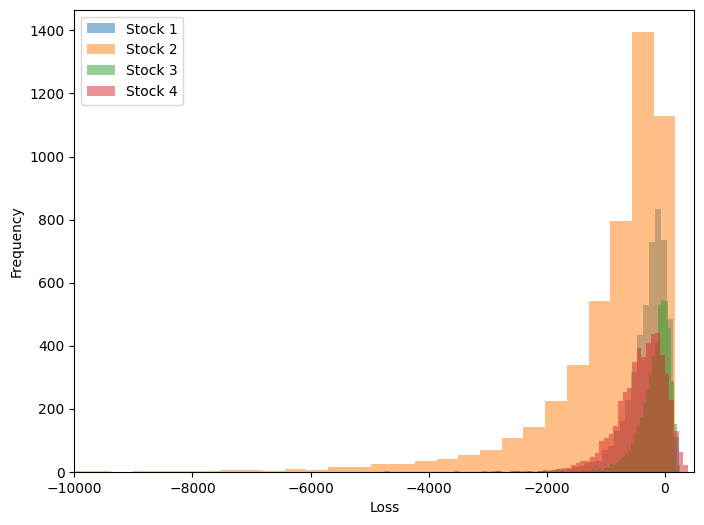

In [35]:
plt.figure(figsize=(8,6))

for i in range(4):
    plt.hist(losses[i], bins=50, alpha=0.5, label=f"Stock {i+1}")
plt.xlim((-10000,500))
plt.legend()
plt.xlabel("Loss")
plt.ylabel("Frequency")
plt.show()

<div align="center">

The fact that most losses are in the negative side means the revenue is positive. A positive loss would mean that we actually lost money.

<>

In [32]:
prices.tail()

,AAPL,NVDA,JPM,SPY
1602,298.970001,220.353180,295.700012,733.729980
1603,302.250000,223.209854,301.980011,741.250000
1604,304.989990,219.254456,303.000000,742.719971
1605,308.820007,215.079330,306.380005,745.640015
1606,308.329987,214.609879,306.739990,750.590027


In [11]:
var95 = np.percentile(losses, 95,axis=1)
var95

array([ 91.25832368,  44.71713516, 132.26911145, 136.5897021 ])

<div align="center">

This losses array([ 91.25832368,  44.71713516, 132.26911145, 136.5897021 ])
is the most amount of losses I can lose with a confidence interval of 95%. But after investing how much?
Well, I guess after buying one stock of every company we are analyzing.

</div>

In [12]:
# var95 shape: (n_rows,), losses shape: (n_rows, n_sims)
mask = losses >= var95[:, None]               # broadcast column-wise
cvar95 = np.where(mask, losses, np.nan)
cvar95 = np.nanmean(cvar95, axis=1)    # Mean of tail losses per row
cvar95

array([133.57099901,  94.20147635, 164.15519549, 214.82833508])

<div align="center">

CVaR, or Conditional Value at Risk measures the **average** loss once a portfolio has exceeded the VaR value. It measures the average loss once the portfolio is in the worst case sceneario.
</div>

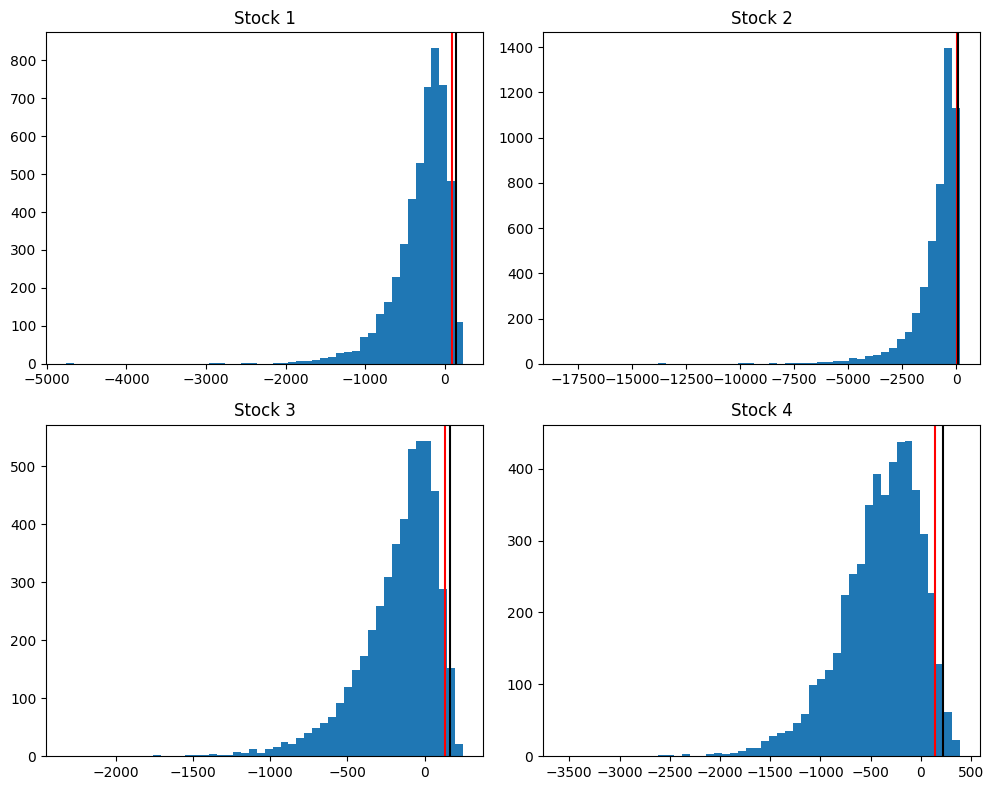

In [13]:

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, ax in enumerate(axes.flatten()):
    ax.hist(losses[i], bins=50)
    ax.set_title(f"Stock {i+1}")
    ax.axvline(var95[i], color="red")
    ax.axvline(cvar95[i], color="black")

plt.tight_layout()
plt.show()

In [14]:
weights = np.array([0.4, 0.3, 0.2, 0.1])

portfolio_paths = np.sum(
    paths * weights[None, :, None],
    axis=1
)
portfolio_losses = (
    portfolio_paths[0]
    - portfolio_paths[-1]
)
portolio_var95=np.percentile(portfolio_losses,95)
print(portolio_var95)
tail=losses[losses>=portolio_var95]

portfolio_cvar95=tail.mean()
print(portfolio_cvar95)

36.529246411392336
107.6563848313448


With the weights=np.array([0.4, 0.3, 0.2, 0.1]) we get a 
$$
VaR=36.55
$$
and 
$$
CVar=107.68
$$
This tells us that the average loss for this portfolio when we are in the worst case scenario is CVaR=107.68

Now what we must do is validate tha Monte Carlo Convergence. We will simulate the paths again from N=500, to N=100,000 and see how is the $VaR$ and $CVaR$ converge to some value

In [15]:
def get_var_and_cvar(n:int)->np.ndarray:
    corraleted_matrix=estimate_Correlation_matrix(returns)
    n_paths=n
    n_assets=4
    years=3
    steps_per_year=252
    paths=simulate_correlated_GBM(
    corr_matrix=corraleted_matrix,
    prices=prices,
    returns=returns,
    n_paths=n,
    n_assets=n_assets,
    years=years,
    steps_per_year=steps_per_year,
        )
    weights = np.array([0.4, 0.3, 0.2, 0.1])

    portfolio_paths = np.sum(
    paths * weights[None, :, None],
    axis=1
    )
    portfolio_losses = (
    portfolio_paths[0]
    - portfolio_paths[-1]
    )
    portolio_var95=np.percentile(portfolio_losses,95)
    tail=losses[losses>=portolio_var95]

    portfolio_cvar95=tail.mean()
    return portolio_var95,portfolio_cvar95




In [16]:
n=np.linspace(1000,10000,10)
VaR=[]
CVaR=[]
for i in n:
    Var95,CvaR95=get_var_and_cvar(int(i))
    VaR.append(Var95)
    CVaR.append(CvaR95)



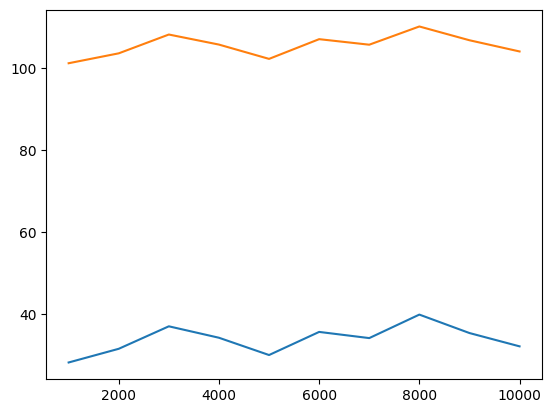

In [17]:
plt.plot(n,np.array(VaR))
plt.plot(n,np.array(CVaR))
plt.show()